## Importing important libraries and modules

In [4]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , root_mean_squared_error


## Fetching and Inspecting the Data

In [5]:
data = pd.read_csv('delivery_time.csv')

print(data.info())
print("--------------------------------")
print("\n\nThe shape of the data is : ",data.shape)
print("--------------------------------")
print("\n\nThe description of the data is as: \n",data.describe())
print("--------------------------------")
print("\n\nIf there is null values in data : \n",data.isnull().sum())
print("\n\n--------------------------------")

data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery Time  21 non-null     float64
 1   Sorting Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes
None
--------------------------------


The shape of the data is :  (21, 2)
--------------------------------


The description of the data is as: 
        Delivery Time  Sorting Time
count      21.000000     21.000000
mean       16.790952      6.190476
std         5.074901      2.542028
min         8.000000      2.000000
25%        13.500000      4.000000
50%        17.830000      6.000000
75%        19.750000      8.000000
max        29.000000     10.000000
--------------------------------


If there is null values in data : 
 Delivery Time    0
Sorting Time     0
dtype: int64


--------------------------------


,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10
5,15.35,6
6,19.00,7
7,9.50,3
8,17.90,10
9,18.75,9


## EDA insights on Data

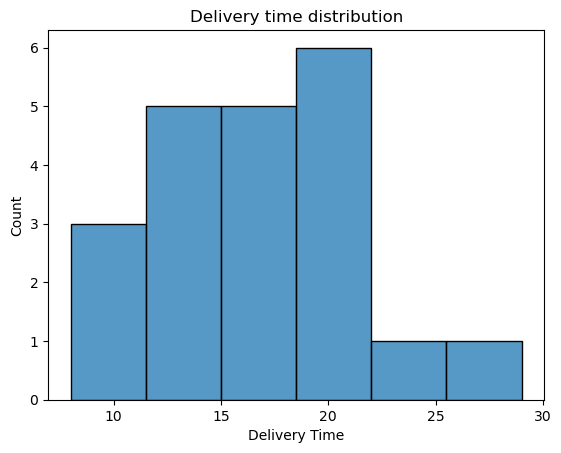

In [6]:
sns.histplot(data['Delivery Time'])
plt.title("Delivery time distribution")
plt.savefig('Graphs/delivery_dist.png')
plt.show()

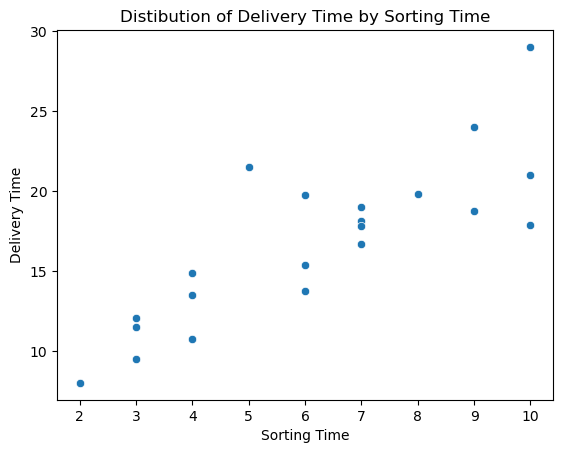

In [7]:
sns.scatterplot(data=data , x = data['Sorting Time'] , y = data['Delivery Time'])
plt.title("Distibution of Delivery Time by Sorting Time")
plt.savefig('Graphs/scatter.png')
plt.show()

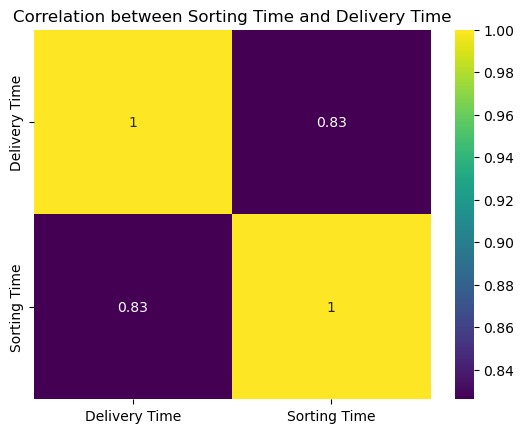

In [8]:
## We can also find the correlation and map it to the heatmap to analyse the correlatiion visually
corr = data.corr()

sns.heatmap(data = corr , annot= True , cmap='viridis')
plt.title("Correlation between Sorting Time and Delivery Time")
plt.savefig('Graphs/correlation.png')
plt.show()

## Model Building 

In [9]:
X = data['Sorting Time'].values.reshape(-1,1)
y = data['Delivery Time'].values.reshape(-1,1)

In [10]:
## Fitting the data points to the model 

regressor = LinearRegression()
regressor.fit(X,y)

LinearRegression()

In [13]:
## Predictions 
y_pred = regressor.predict(X)


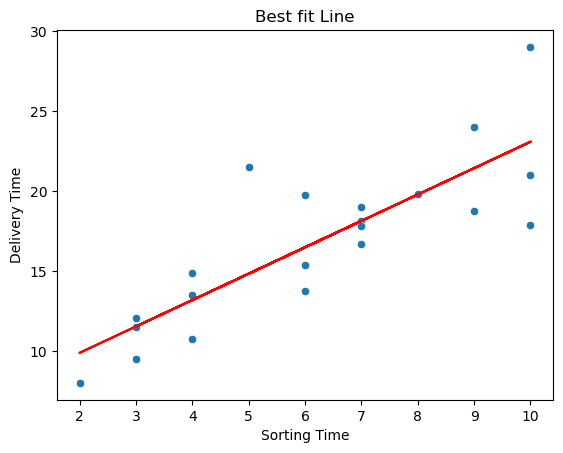

In [16]:
sns.scatterplot(data=data , x = data['Sorting Time'] , y = data['Delivery Time'])
plt.plot(X,y_pred , color = 'red')
plt.title("Best fit Line")
plt.savefig('Graphs/scatter_best_fit.png')
plt.show()

## Model Evaluation using metrics

In [17]:
score = r2_score(y,y_pred)
error = root_mean_squared_error(y,y_pred)
print(f"The score of the model is {score:.2f} ")
print(f"The Root mean square value is {error : .2f}")

The score of the model is 0.68 
The Root mean square value is  2.79
